In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

import joblib
import random

sns.set(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# 1. Chargement du dataset et exploration de sa structure

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print("Shape du DataFrame:", df.shape)
df.head()


Shape du DataFrame: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


***Description des features du dataset California Housing***

- **MedInc**  
  Revenu médian des ménages dans le quartier (en dizaines de milliers de dollars).  

- **HouseAge**  
  Âge médian des habitations du quartier (en années) : Reflète l’ancienneté des constructions.

- **AveRooms**  
  Nombre moyen de pièces par logement dans le quartier.  


- **AveBedrms**  
  Nombre moyen de chambres à coucher par logement.  

- **Population**  
  Nombre total d’habitants dans le district : Représente la densité démographique.

- **AveOccup**  
  Nombre moyen d’occupants par logement : Indique la taille moyenne des familles ou le niveau de sur-occupation.

- **Latitude**  
  Latitude géographique du district (coordonnées GPS) : Permet de situer le quartier du nord au sud de la Californie.

- **Longitude**  
  Longitude géographique du district (coordonnées GPS) : Permet de situer le quartier d’est en ouest de la Californie.

- **MedHouseVal**  
  Valeur médiane des maisons dans le district (en centaines de milliers de dollars) : C’est la **cible originale** que l’on cherche à prédire.




In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


# 2. Définition des cibles et des features

In [5]:
# Cible brute (prix médian réel en centaines de milliers de dollars)
target_raw = "MedHouseVal"

# Cible transformée (log), mais on justifie ce choix juste après, n’anticipez pas les choses Aicha et Douae !
df["MedHouseVal_log"] = np.log1p(df["MedHouseVal"])  # np.log1p(y) = log(1 + y)
target = "MedHouseVal_log"

# Features initiales : toutes les colonnes sauf les deux cibles
features = [c for c in df.columns if c not in [target_raw, target]]

print("Features:", features)
print("Target brute:", target_raw)
print("Target transformée:", target)


Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target brute: MedHouseVal
Target transformée: MedHouseVal_log


# 3. Analyse exploratoire de la cible

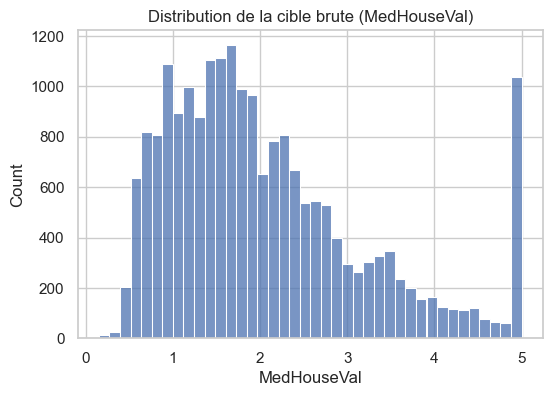

Skewness de la cible brute: 0.9777632739098345


In [6]:
# 3.1 Distribution brute de MedHouseVal
plt.figure(figsize=(6,4))
sns.histplot(df[target_raw], bins=40)
plt.title("Distribution de la cible brute (MedHouseVal)")
plt.xlabel("MedHouseVal")
plt.show()

skew_target = df[target_raw].skew()
print("Skewness de la cible brute:", float(skew_target))


La *skewness* (ou asymétrie) mesure à quel point la distribution d’une variable
s’étend davantage d’un côté que de l’autre.

Mathématiquement, elle est définie par :

$$
\text{Skew}(Y) = \frac{E[(Y - \mu)^3]}{\sigma^3}
$$




* **Skew > 1 : très asymétrique.**

* **Skew entre 0.5 et 1 : modérément asymétrique.**

* **Skew proche de 0 : plutôt symétrique.**

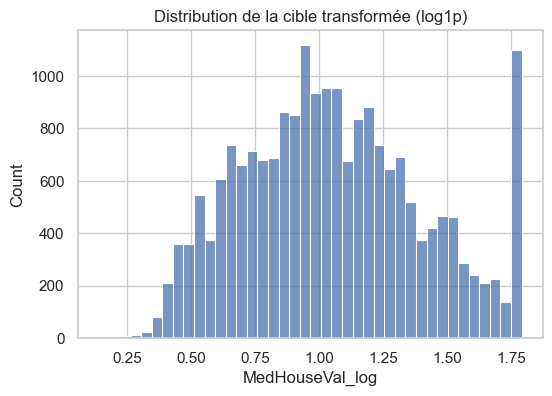

Skewness de la cible log: 0.2759390509171133


In [7]:
# 3.2 Transformation log
plt.figure(figsize=(6,4))
sns.histplot(df[target], bins=40)
plt.title("Distribution de la cible transformée (log1p)")
plt.xlabel("MedHouseVal_log")
plt.show()

skew_target_log = df[target].skew()
print("Skewness de la cible log:", float(skew_target_log))


La skewness passe d’environ 0.98 à quelque chose près de 0, donc la distribution devient beaucoup plus symétrique. L’optimisation de la fonction de coût via gradient descent est plus stable.


# 4. Analyse exploratoire des features

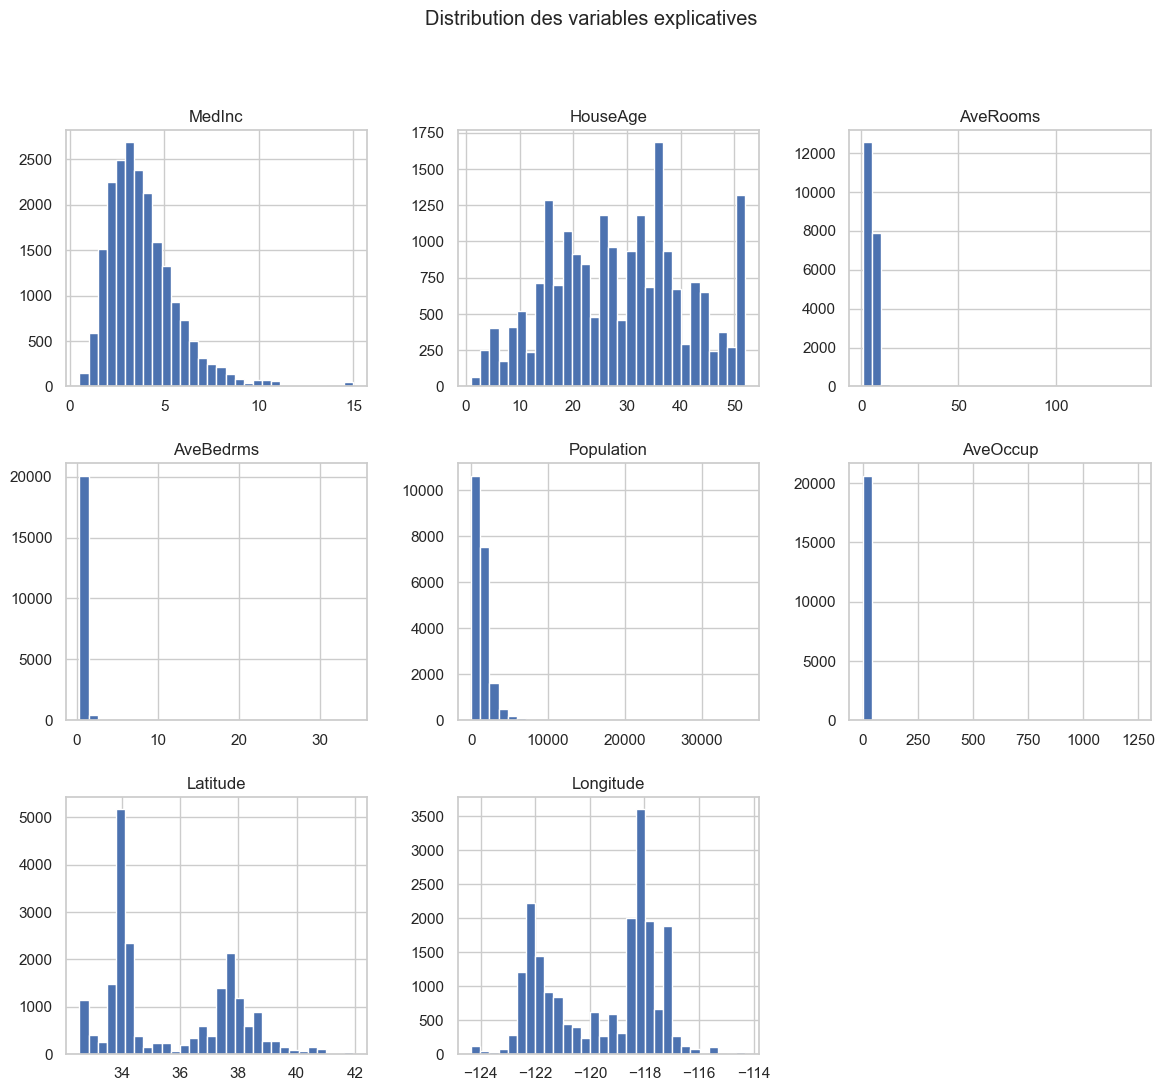

In [9]:
# 4.1 Distributions de toutes les variables explicatives

df[features].hist(bins=30, figsize=(14,12))
plt.suptitle("Distribution des variables explicatives")
plt.show()


In [10]:
# 4.2 Skewness des features

skew_values = df[features].skew().sort_values(ascending=False)
skew_values


AveOccup      97.639561
AveBedrms     31.316956
AveRooms      20.697869
Population     4.935858
MedInc         1.646657
Latitude       0.465953
HouseAge       0.060331
Longitude     -0.297801
dtype: float64

# 5. Feature engineering

In [11]:
# 5.1 Feature géographique (GeoAxis)

X_geo = df[["Latitude", "Longitude"]].values
y_geo = df["MedHouseVal_log"].values  # cible en log

lin_geo = LinearRegression()
lin_geo.fit(X_geo, y_geo)

a, b = lin_geo.coef_
print("Coefficients géographiques (Latitude, Longitude) :", a, b)

# Nouvelle feature : projection géographique sur l'axe prix
df["GeoAxis"] = lin_geo.predict(X_geo)

corr_lr = np.corrcoef(df["GeoAxis"], y_geo)[0, 1]
print("Corrélation entre GeoAxis et target log :", corr_lr)


Coefficients géographiques (Latitude, Longitude) : -0.23791995849258257 -0.24048599382010843
Corrélation entre GeoAxis et target log : 0.5442697051200454


In [12]:
# 5.2 Feature engineering
def add_features(df) :
    df = df.copy()

    #  Identification automatique des features explicatives
    features = [c for c in df.columns if c not in ["MedHouseVal", "MedHouseVal_log"]]
    skew_values = df[features].skew()

    #  Colonnes très skewed (skew > 1)
    skew_threshold = 1.0
    skewed_cols = skew_values[skew_values > skew_threshold].index.tolist()
    print("Features très asymétriques (skew > 1):", skewed_cols)

    #  Transformation log1p des features très skewed
    for col in skewed_cols:
        df[col + "_log1p"] = np.log1p(df[col])

    #  Ratios structurels pertinents

    # Nombre moyen de pièces par occupant (densité de confort)
    df["Rooms_per_occupant"] = df["AveRooms"] / df["AveOccup"]
    # Ratio chambres / pièces (style de logement)
    df["Bedrooms_per_room"] = df["AveRooms"] / df["AveBedrms"]


    # Interaction revenu x géographie
    df["MedInc_times_GeoAxis"] = df["MedInc"] * df["GeoAxis"]

    # Nettoyage des inf
    df = df.replace([np.inf, -np.inf], np.nan)
    new_features = ["Rooms_per_occupant", "Bedrooms_per_room", "MedInc_times_GeoAxis"]
    for col in new_features:
        if col in df.columns:
            median_value = df[col].median(skipna=True)
            df[col] = df[col].fillna(median_value)

    return df

df_fe = add_features(df)
print("Shape après feature engineering:", df_fe.shape)
df_fe.head()


Features très asymétriques (skew > 1): ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
Shape après feature engineering: (20640, 19)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,MedHouseVal_log,GeoAxis,MedInc_log1p,AveRooms_log1p,AveBedrms_log1p,Population_log1p,AveOccup_log1p,Rooms_per_occupant,Bedrooms_per_room,MedInc_times_GeoAxis
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,1.709464,1.161033,2.232720,2.077455,0.704982,5.777652,1.268511,2.732919,6.821705,9.665833
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,1.522790,1.163387,2.230165,1.979364,0.678988,7.784057,1.134572,2.956685,6.418626,9.657738
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,1.508733,1.170576,2.111110,2.228738,0.729212,6.208590,1.335596,2.957661,7.721053,8.495336
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,1.484555,1.172980,1.893579,1.919471,0.729025,6.326149,1.266369,2.283154,5.421277,6.619246
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,1.486592,1.172980,1.578195,1.985385,0.732888,6.338594,1.157342,2.879646,5.810714,4.511518


Features très asymétriques (skew > 1): ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
Corrélation des features avec la cible log (triées):

MedHouseVal_log         1.000000
MedHouseVal             0.979741
MedInc_times_GeoAxis    0.748440
MedInc_log1p            0.684751
MedInc                  0.676439
GeoAxis                 0.544270
Bedrooms_per_room       0.371098
AveRooms_log1p          0.222530
Rooms_per_occupant      0.193101
AveRooms                0.139036
HouseAge                0.088588
Population_log1p        0.007862
Population             -0.000176
AveOccup               -0.023449
Longitude              -0.033463
AveBedrms              -0.055263
AveBedrms_log1p        -0.094108
Latitude               -0.175914
AveOccup_log1p         -0.238721
Name: MedHouseVal_log, dtype: float64


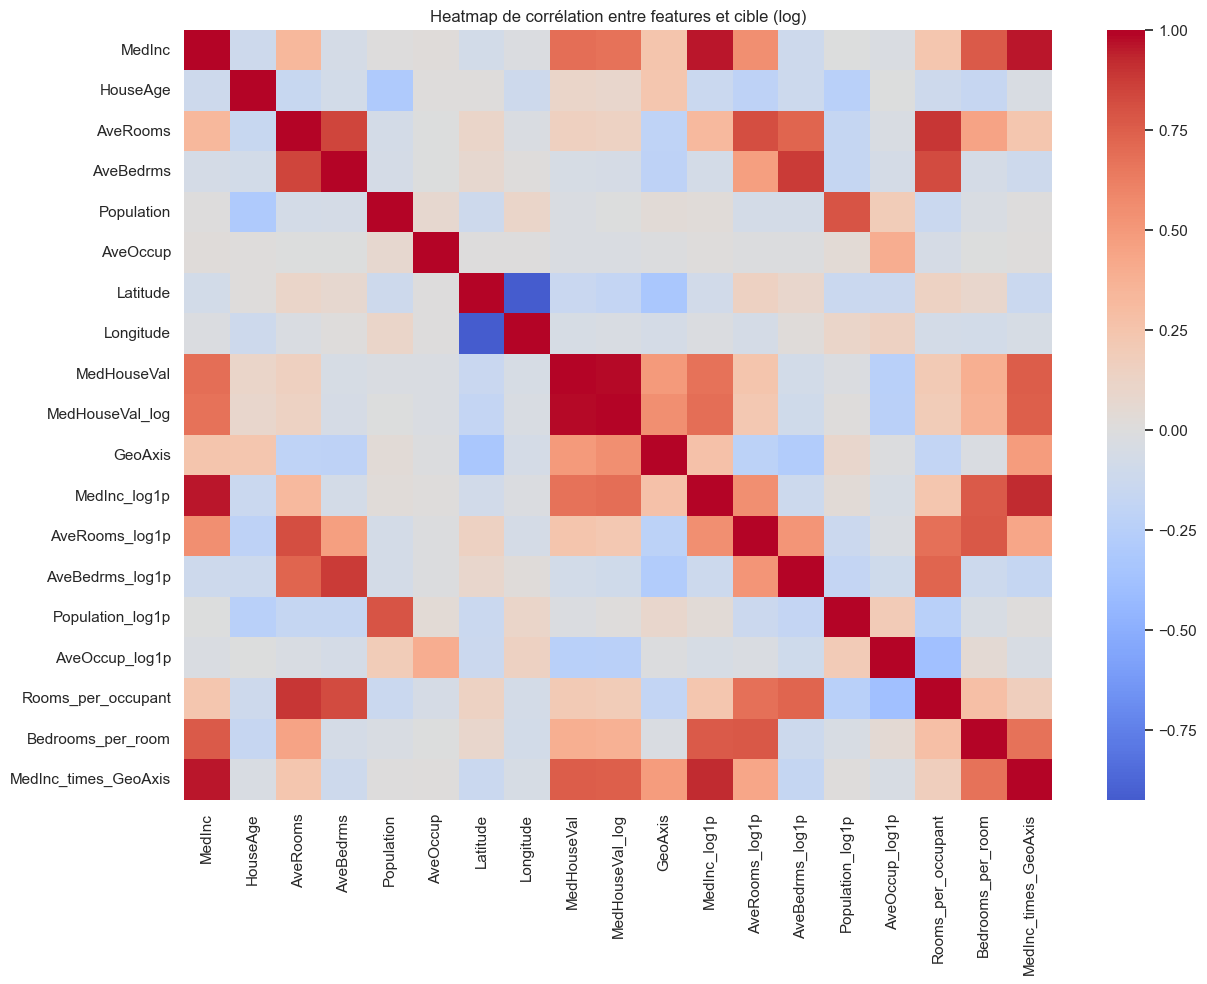

In [13]:
# 5.3 Analyse de corrélation des features (après feature engineering)

# On recalcule df_fe pour être sûr
df_fe = add_features(df)

# Récupération des features finales
features_fe = [c for c in df_fe.columns if c not in ["MedHouseVal", "MedHouseVal_log"]]

# Matrice de corrélation complète
corr_matrix = df_fe.corr()

# Affichage trié par corrélation absolue avec la cible
corr_target = corr_matrix["MedHouseVal_log"].sort_values(ascending=False)

print("Corrélation des features avec la cible log (triées):\n")
print(corr_target)

# Heatmap de corrélation
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Heatmap de corrélation entre features et cible (log)")
plt.show()


# 6. Définition finale des features + cibles & split des données


In [14]:
# Features finales : toutes les colonnes sauf cibles brute / log
features_fe = [c for c in df_fe.columns if c not in [target_raw, target]]

X = df_fe[features_fe].values
y_raw = df_fe[target_raw].values
y_log = df_fe[target].values


print("X shape:", X.shape)
print("y_raw shape:", y_raw.shape)
print("y_log shape:", y_log.shape)


X shape: (20640, 17)
y_raw shape: (20640,)
y_log shape: (20640,)


**6.1 Split train / validation / test**

In [15]:
X_train_full, X_test, y_train_full, y_test, y_train_full_raw, y_test_raw = train_test_split(
    X, y_log, y_raw, test_size=0.2, random_state=RANDOM_STATE )


print("Train:", X_train_full.shape, "Test:", X_test.shape)

Train: (16512, 17) Test: (4128, 17)


# 7. Scaling (StandardScaler)

In [16]:
scaler = StandardScaler()

# On apprend la normalisation UNIQUEMENT sur le train
scaler.fit(X_train_full)

# On applique la même transformation partout
X_test_scaled       = scaler.transform(X_test)
X_train_full_scaled = scaler.transform(X_train_full)

n_inputs = X_test_scaled.shape[1]
print("Nombre de features après FE + scaling:", n_inputs)

Nombre de features après FE + scaling: 17


# 8. Fonctions d’évaluation du MLP et des Baselines

**Les modèles deep learning sont ici entraînés sur la cible transformée en log (MedHouseVal_log), mais l'évaluation finale est faite en échelle réelle(MedHouseVal) afin d'être interprétable.**

In [17]:
def eval_predictions_raw(y_true_raw, y_pred_log):

    y_pred_raw = np.expm1(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    mae  = mean_absolute_error(y_true_raw, y_pred_raw)
    r2   = r2_score(y_true_raw, y_pred_raw)

    return {"RMSE": rmse, "MAE": mae, "R2": r2}


In [18]:
def train_eval_sklearn_model(name, model, X_tr, y_tr_raw, X_te, y_te_raw):

    model.fit(X_tr, y_tr_raw)
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    metrics = {
        "Model": name,
        "RMSE_train": np.sqrt(mean_squared_error(y_tr_raw, y_tr_pred)),
        "RMSE_test": np.sqrt(mean_squared_error(y_te_raw, y_te_pred)),
        "MAE_test": mean_absolute_error(y_te_raw, y_te_pred),
        "R2_test": r2_score(y_te_raw, y_te_pred),
    }
    return model, metrics  



# 9. Définitions des Baselines

In [19]:
baseline_results = []

#  Dummy (prédit la moyenne)
dummy = DummyRegressor(strategy="mean")
_, m_dummy = train_eval_sklearn_model(
    "Dummy(moyenne)", dummy,
    X_train_full_scaled, y_train_full_raw,
    X_test_scaled, y_test_raw
)
baseline_results.append(m_dummy)

# Régression linéaire
lin_reg = LinearRegression()
_, m_lin = train_eval_sklearn_model(
    "LinearRegression", lin_reg,
    X_train_full_scaled, y_train_full_raw,
    X_test_scaled, y_test_raw
)
baseline_results.append(m_lin)

pd.DataFrame(baseline_results)


,Model,RMSE_train,RMSE_test,MAE_test,R2_test
0,Dummy(moyenne),1.156191,1.144856,0.906069,-0.000219
1,LinearRegression,0.656378,0.684467,0.480716,0.642482


# 10. Modèles utilisés

### Random Forest

In [20]:
def rf_gridsearch(x_train, y_train):
    """
    Entraîne un modèle RandomForestRegressor optimisé avec GridSearchCV
    avec moins de combinaisons pour accélérer la recherche.
    """

    # Grille réduite pour limiter le nombre de combinaisons
    param_grid = {
        'n_estimators': [100, 200],          # Nombre d'arbres
        'max_depth': [None, 20],             # Profondeur maximale
        'min_samples_split': [2, 5],         # Nombre minimal d'échantillons pour diviser un noeud
        'min_samples_leaf': [1, 2],          # Nombre minimal d'échantillons par feuille
        'max_features': ['sqrt', 'log2']     # Features considérées à chaque split
    }

    # Création du modèle
    rf = RandomForestRegressor(random_state=0)

    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=2
    )

    # Entraînement
    grid_search.fit(x_train, y_train)

    return (
        grid_search.best_estimator_,
        grid_search.best_params_,
        grid_search.best_score_
    )


In [21]:
best_model, best_params, best_score = rf_gridsearch(X_train_full_scaled, y_train_full)

print("Meilleurs hyperparamètres :", best_params)
print("Score CV (MSE négatif) :", best_score)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Meilleurs hyperparamètres : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Score CV (MSE négatif) : -0.021189342808385053


In [22]:
# Créer le modèle Random Forest avec les paramètres optimisés
rf_model = RandomForestRegressor(
    n_estimators=200,           # Nombre d'arbres
    max_depth=20,               # Profondeur maximale des arbres
    min_samples_split=2,        # Nombre minimum d'échantillons pour diviser un nœud
    min_samples_leaf=1,         # Nombre minimum d'échantillons dans une feuille
    max_features='sqrt',        # Nombre de features à considérer pour la meilleure division
    bootstrap=False,            # Ne pas utiliser le bootstrap (échantillonnage avec remise)
    random_state=42,            # Pour la reproductibilité
    n_jobs=-1                   # Utiliser tous les cœurs disponibles
)

print(" VALIDATION CROISÉE (5-FOLD)")

# Configuration de la validation croisée
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

# Stocker les résultats pour chaque fold
results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full_scaled), 1):
    print(f"  Fold {fold}/{n_splits}")
    
    # Séparation des données pour ce fold
    X_train_fold = X_train_full_scaled[train_idx]
    X_val_fold = X_train_full_scaled[val_idx]
    y_train_fold = y_train_full[train_idx]
    y_val_fold = y_train_full[val_idx]
    y_train_raw_fold = y_train_full_raw[train_idx]
    y_val_raw_fold = y_train_full_raw[val_idx]
    
    # Entraînement sur le fold d'entraînement
    rf_model.fit(X_train_fold, y_train_fold)
    
    # Prédictions sur le fold de validation
    y_val_pred_log = rf_model.predict(X_val_fold)
    y_val_pred_raw = np.expm1(y_val_pred_log)
    
    # Calcul des métriques
    mse = mean_squared_error(y_val_raw_fold, y_val_pred_raw)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val_raw_fold, y_val_pred_raw)
    r2 = r2_score(y_val_raw_fold, y_val_pred_raw)
    
    # Stocker les résultats
    results.append({
        'fold': fold,
        'train_samples': len(train_idx),
        'val_samples': len(val_idx),
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

    print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# Créer un DataFrame avec les résultats
cv_results_df = pd.DataFrame(results)

# Afficher les résultats détaillés
print("DÉTAIL PAR FOLD:")
display(cv_results_df)  

 VALIDATION CROISÉE (5-FOLD)
  Fold 1/5
MSE: 0.2542, RMSE: 0.5042, MAE: 0.3261, R²: 0.8158
  Fold 2/5
MSE: 0.2349, RMSE: 0.4847, MAE: 0.3110, R²: 0.8232
  Fold 3/5
MSE: 0.2366, RMSE: 0.4865, MAE: 0.3088, R²: 0.8226
  Fold 4/5
MSE: 0.2616, RMSE: 0.5114, MAE: 0.3167, R²: 0.8058
  Fold 5/5
MSE: 0.2368, RMSE: 0.4866, MAE: 0.3160, R²: 0.8170
DÉTAIL PAR FOLD:


,fold,train_samples,val_samples,MSE,RMSE,MAE,R2
0,1,13209,3303,0.254238,0.504220,0.326105,0.815768
1,2,13209,3303,0.234909,0.484674,0.311007,0.823155
2,3,13210,3302,0.236643,0.486460,0.308756,0.822551
3,4,13210,3302,0.261565,0.511434,0.316676,0.805838
4,5,13210,3302,0.236754,0.486573,0.315978,0.817022


In [23]:
# Calculer les moyennes et écarts-types
mean_results = {
    'MSE_mean': cv_results_df['MSE'].mean(),
    'MSE_std': cv_results_df['MSE'].std(),
    'RMSE_mean': cv_results_df['RMSE'].mean(),
    'RMSE_std': cv_results_df['RMSE'].std(),
    'MAE_mean': cv_results_df['MAE'].mean(),
    'MAE_std': cv_results_df['MAE'].std(),
    'R2_mean': cv_results_df['R2'].mean(),
    'R2_std': cv_results_df['R2'].std()
}

print("STATISTIQUES GLOBALES (moyenne ± écart-type):")
print(f"MSE:  {mean_results['MSE_mean']:.4f} ± {mean_results['MSE_std']:.4f}")
print(f"RMSE: {mean_results['RMSE_mean']:.4f} ± {mean_results['RMSE_std']:.4f}")
print(f"MAE:  {mean_results['MAE_mean']:.4f} ± {mean_results['MAE_std']:.4f}")
print(f"R²:   {mean_results['R2_mean']:.4f} ± {mean_results['R2_std']:.4f}")

STATISTIQUES GLOBALES (moyenne ± écart-type):
MSE:  0.2448 ± 0.0122
RMSE: 0.4947 ± 0.0123
MAE:  0.3157 ± 0.0067
R²:   0.8169 ± 0.0070


In [24]:
# Entraîner le modèle sur tout l'ensemble d'entraînement
print("Entraînement du modèle sur tout le training set")
rf_model.fit(X_train_full_scaled, y_train_full)

# Faire des prédictions
y_pred_train = rf_model.predict(X_train_full_scaled)
y_pred_test = rf_model.predict(X_test_scaled)

# Convertir en valeurs originales
y_pred_train_2 = np.expm1(y_pred_train)
y_pred_test2 = np.expm1(y_pred_test)

# Calculer les métriques finales
train_rmse = np.sqrt(mean_squared_error(y_train_full_raw, y_pred_train_2))
test_rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred_test2))
train_r2 = r2_score(y_train_full_raw, y_pred_train_2)
test_r2 = r2_score(y_test_raw, y_pred_test2)
train_mae = mean_absolute_error(y_train_full_raw, y_pred_train_2)
test_mae = mean_absolute_error(y_test_raw, y_pred_test2)

results_df = pd.DataFrame({
    "RMSE": [train_rmse, test_rmse],
    "R2": [train_r2, test_r2],
    "MAE": [train_mae, test_mae]
}, index=["Train", "Test"])

display(results_df)

Entraînement du modèle sur tout le training set


,RMSE,R2,MAE
Train,0.039028,0.998861,0.021956
Test,0.484378,0.820955,0.308645


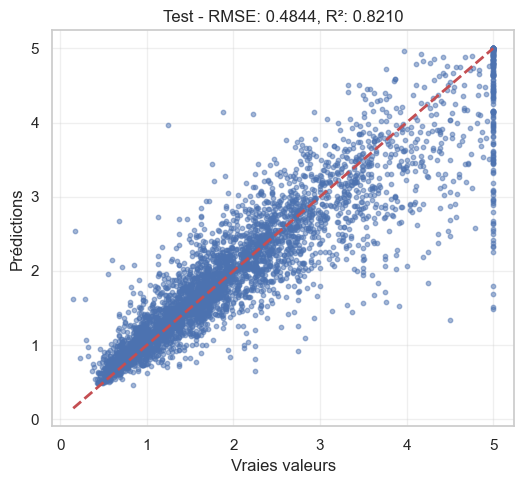

In [25]:
#VISUALISATIONS
plt.figure(figsize=(15, 5))

# Prédictions vs Réelles
plt.subplot(1, 3, 1)
plt.scatter(y_test_raw, y_pred_test2, alpha=0.5, s=10)
plt.plot([y_test_raw.min(), y_test_raw.max()], 
         [y_test_raw.min(), y_test_raw.max()], 'r--', lw=2)
plt.xlabel('Vraies valeurs')
plt.ylabel('Prédictions')
plt.title(f'Test - RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### KNN

In [26]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

def knn_with_gridsearch_reg(x_train_scaled, y_train):
    """
    Entraîne un modèle KNN Regressor optimisé avec GridSearchCV.
    """

    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'p': [1, 2]
    }

    knn = KNeighborsRegressor()

    grid_search = GridSearchCV(
        estimator=knn,
        param_grid=param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(x_train_scaled, y_train)

    return (
        grid_search.best_estimator_,
        grid_search.best_params_,
        grid_search.best_score_
    )

In [27]:
best_model, best_params, best_score = knn_with_gridsearch_reg(X_train_full_scaled, y_train_full)

print("Meilleurs hyperparamètres :", best_params)
print("Score CV (MSE négatif) :", best_score)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Meilleurs hyperparamètres : {'metric': 'manhattan', 'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
Score CV (MSE négatif) : -0.024409092818539868


In [28]:
# Modèle KNN optimisé
best_KNN_model = KNeighborsRegressor(
    n_neighbors=11,
    weights='distance',
    metric='manhattan',
    p=1
)

In [29]:
print(" VALIDATION CROISÉE (5-FOLD)")

# Configuration de la validation croisée
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

# Stocker les résultats
results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full_scaled), 1):
    print(f"  Fold {fold}/{n_splits}")
    
    # Données fold
    X_train_fold = X_train_full_scaled[train_idx]
    X_val_fold   = X_train_full_scaled[val_idx]
    y_train_fold = y_train_full[train_idx]
    y_val_fold   = y_train_full[val_idx]
    y_train_raw_fold = y_train_full_raw[train_idx]
    y_val_raw_fold   = y_train_full_raw[val_idx]

    # Entraînement
    best_KNN_model.fit(X_train_fold, y_train_fold)

    # Prédictions log
    y_val_pred_log = best_KNN_model.predict(X_val_fold)
    # Conversion vers échelle originale
    y_val_pred_raw = np.expm1(y_val_pred_log)

    # Métriques
    mse = mean_squared_error(y_val_raw_fold, y_val_pred_raw)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val_raw_fold, y_val_pred_raw)
    r2 = r2_score(y_val_raw_fold, y_val_pred_raw)

    # Stockage
    results.append({
        'fold': fold,
        'train_samples': len(train_idx),
        'val_samples': len(val_idx),
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

    print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")


# Résultats folds
cv_results_df = pd.DataFrame(results)
print("DÉTAIL PAR FOLD:")
display(cv_results_df)

 VALIDATION CROISÉE (5-FOLD)
  Fold 1/5
MSE: 0.2929, RMSE: 0.5412, MAE: 0.3585, R²: 0.7877
  Fold 2/5
MSE: 0.2798, RMSE: 0.5289, MAE: 0.3454, R²: 0.7894
  Fold 3/5
MSE: 0.2656, RMSE: 0.5154, MAE: 0.3405, R²: 0.8008
  Fold 4/5
MSE: 0.3017, RMSE: 0.5493, MAE: 0.3510, R²: 0.7760
  Fold 5/5
MSE: 0.2803, RMSE: 0.5294, MAE: 0.3475, R²: 0.7834
DÉTAIL PAR FOLD:


,fold,train_samples,val_samples,MSE,RMSE,MAE,R2
0,1,13209,3303,0.292928,0.541228,0.358471,0.787732
1,2,13209,3303,0.279760,0.528923,0.345381,0.789390
2,3,13210,3302,0.265621,0.515384,0.340544,0.800822
3,4,13210,3302,0.301714,0.549285,0.351021,0.776035
4,5,13210,3302,0.280302,0.529435,0.347514,0.783365


In [30]:
# Moyennes & Écarts-types
mean_results = {
    'MSE_mean': cv_results_df['MSE'].mean(),
    'MSE_std':  cv_results_df['MSE'].std(),
    'RMSE_mean': cv_results_df['RMSE'].mean(),
    'RMSE_std':  cv_results_df['RMSE'].std(),
    'MAE_mean': cv_results_df['MAE'].mean(),
    'MAE_std':  cv_results_df['MAE'].std(),
    'R2_mean':  cv_results_df['R2'].mean(),
    'R2_std':   cv_results_df['R2'].std()
}

print("STATISTIQUES GLOBALES (moyenne ± écart-type):")
print(f"MSE:  {mean_results['MSE_mean']:.4f} ± {mean_results['MSE_std']:.4f}")
print(f"RMSE: {mean_results['RMSE_mean']:.4f} ± {mean_results['RMSE_std']:.4f}")
print(f"MAE:  {mean_results['MAE_mean']:.4f} ± {mean_results['MAE_std']:.4f}")
print(f"R²:   {mean_results['R2_mean']:.4f} ± {mean_results['R2_std']:.4f}")

STATISTIQUES GLOBALES (moyenne ± écart-type):
MSE:  0.2841 ± 0.0138
RMSE: 0.5329 ± 0.0130
MAE:  0.3486 ± 0.0067
R²:   0.7875 ± 0.0091


In [31]:
print("Entraînement du modèle KNN sur tout le training set")
best_KNN_model.fit(X_train_full_scaled, y_train_full)

# Prédictions
y_pred_train = best_KNN_model.predict(X_train_full_scaled)
y_pred_test  = best_KNN_model.predict(X_test_scaled)

# Retour échelle réelle
y_pred_train_2 = np.expm1(y_pred_train)
y_pred_test2 = np.expm1(y_pred_test)

# Métriques finales
train_rmse = np.sqrt(mean_squared_error(y_train_full_raw, y_pred_train_2))
test_rmse  = np.sqrt(mean_squared_error(y_test_raw, y_pred_test2))

train_r2 = r2_score(y_train_full_raw, y_pred_train_2)
test_r2  = r2_score(y_test_raw, y_pred_test2)

train_mae = mean_absolute_error(y_train_full_raw, y_pred_train_2)
test_mae  = mean_absolute_error(y_test_raw, y_pred_test2)

results_df = pd.DataFrame({
    "RMSE": [train_rmse, test_rmse],
    "R2":   [train_r2,   test_r2],
    "MAE":  [train_mae,  test_mae]
}, index=["Train", "Test"])

display(results_df)

Entraînement du modèle KNN sur tout le training set


,RMSE,R2,MAE
Train,2.452669e-16,1.000000,1.425381e-16
Test,5.330366e-01,0.783176,3.479302e-01


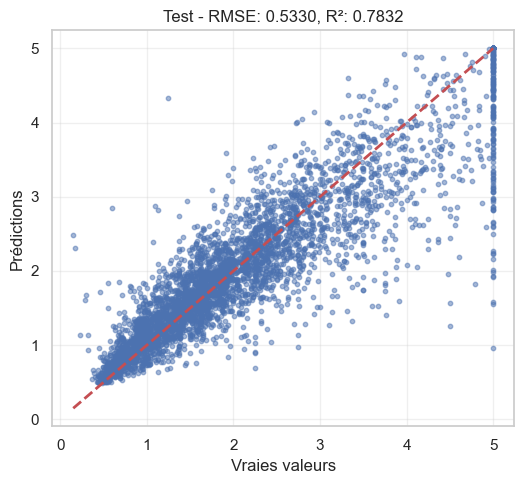

In [32]:
# Visualisation
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_test_raw, y_pred_test2, alpha=0.5, s=10)
plt.plot([y_test_raw.min(), y_test_raw.max()],
         [y_test_raw.min(), y_test_raw.max()], 'r--', lw=2)
plt.xlabel('Vraies valeurs')
plt.ylabel('Prédictions')
plt.title(f'Test - RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### MLP

In [40]:
def mlp_with_gridsearch_reg(x_train_scaled, y_train):
    """
    Entraîne un modèle MLPRegressor optimisé avec GridSearchCV.
    """

    param_grid = {
        'hidden_layer_sizes': [(32,), (64,), (128,), (64, 32), (128, 64)],
        'activation': ['relu', 'tanh'],
        'solver': ['adam'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate': ['constant', 'adaptive'],
        'max_iter': [500]
    }

    mlp = MLPRegressor(random_state=0)

    grid_search = GridSearchCV(
        estimator=mlp,
        param_grid=param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=2
    )

    grid_search.fit(x_train_scaled, y_train)

    return (
        grid_search.best_estimator_,
        grid_search.best_params_,
        grid_search.best_score_
    )


In [41]:
best_model, best_params, best_score = mlp_with_gridsearch_reg(X_train_full_scaled, y_train_full)

print("Meilleurs hyperparamètres :", best_params)
print("Score CV (MSE négatif) :", best_score)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Meilleurs hyperparamètres : {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (128, 64), 'learning_rate': 'constant', 'max_iter': 500, 'solver': 'adam'}
Score CV (MSE négatif) : -0.023936599952295735


In [43]:
best_MLP_model = best_model  

print(" VALIDATION CROISÉE (5-FOLD)")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)

results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full_scaled), 1):
    print(f"  Fold {fold}/{n_splits}")
    
    X_train_fold = X_train_full_scaled[train_idx]
    X_val_fold   = X_train_full_scaled[val_idx]
    y_train_fold = y_train_full[train_idx]
    y_val_fold   = y_train_full[val_idx]
    y_train_raw_fold = y_train_full_raw[train_idx]
    y_val_raw_fold   = y_train_full_raw[val_idx]

    best_MLP_model.fit(X_train_fold, y_train_fold)

    y_val_pred_log = best_MLP_model.predict(X_val_fold)
    y_val_pred_raw = np.expm1(y_val_pred_log)

    mse = mean_squared_error(y_val_raw_fold, y_val_pred_raw)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val_raw_fold, y_val_pred_raw)
    r2  = r2_score(y_val_raw_fold, y_val_pred_raw)

    results.append({
        'fold': fold,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2':  r2
    })

    print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")


 VALIDATION CROISÉE (5-FOLD)
  Fold 1/5
MSE: 0.3012, RMSE: 0.5488, MAE: 0.3562, R²: 0.7851
  Fold 2/5
MSE: 0.2738, RMSE: 0.5233, MAE: 0.3498, R²: 0.7831
  Fold 3/5
MSE: 0.2856, RMSE: 0.5344, MAE: 0.3498, R²: 0.7919
  Fold 4/5
MSE: 0.2979, RMSE: 0.5458, MAE: 0.3527, R²: 0.7819
  Fold 5/5
MSE: 0.2750, RMSE: 0.5244, MAE: 0.3482, R²: 0.7851


In [44]:
cv_results_df = pd.DataFrame(results)
print("DÉTAIL PAR FOLD:")
display(cv_results_df)

mean_results = {
    'MSE_mean': cv_results_df['MSE'].mean(),
    'MSE_std':  cv_results_df['MSE'].std(),
    'RMSE_mean': cv_results_df['RMSE'].mean(),
    'RMSE_std':  cv_results_df['RMSE'].std(),
    'MAE_mean': cv_results_df['MAE'].mean(),
    'MAE_std':  cv_results_df['MAE'].std(),
    'R2_mean':  cv_results_df['R2'].mean(),
    'R2_std':   cv_results_df['R2'].std()
}

print("STATISTIQUES GLOBALES (moyenne ± écart-type):")
print(f"MSE:  {mean_results['MSE_mean']:.4f} ± {mean_results['MSE_std']:.4f}")
print(f"RMSE: {mean_results['RMSE_mean']:.4f} ± {mean_results['RMSE_std']:.4f}")
print(f"MAE:  {mean_results['MAE_mean']:.4f} ± {mean_results['MAE_std']:.4f}")
print(f"R²:   {mean_results['R2_mean']:.4f} ± {mean_results['R2_std']:.4f}")


DÉTAIL PAR FOLD:


,fold,MSE,RMSE,MAE,R2
0,1,0.301211,0.548826,0.356215,0.785095
1,2,0.273818,0.523276,0.349771,0.783099
2,3,0.285552,0.534371,0.349792,0.791926
3,4,0.297936,0.545835,0.352679,0.781936
4,5,0.274958,0.524364,0.348204,0.785073


STATISTIQUES GLOBALES (moyenne ± écart-type):
MSE:  0.2867 ± 0.0127
RMSE: 0.5353 ± 0.0118
MAE:  0.3513 ± 0.0032
R²:   0.7854 ± 0.0039


In [45]:
print("Entraînement du MLP sur tout le training set")
best_MLP_model.fit(X_train_full_scaled, y_train_full)

y_pred_train = best_MLP_model.predict(X_train_full_scaled)
y_pred_test  = best_MLP_model.predict(X_test_scaled)

y_pred_train_2 = np.expm1(y_pred_train)
y_pred_test_2  = np.expm1(y_pred_test)

train_rmse = np.sqrt(mean_squared_error(y_train_full_raw, y_pred_train_2))
test_rmse  = np.sqrt(mean_squared_error(y_test_raw, y_pred_test_2))

train_r2 = r2_score(y_train_full_raw, y_pred_train_2)
test_r2  = r2_score(y_test_raw, y_pred_test_2)

train_mae = mean_absolute_error(y_train_full_raw, y_pred_train_2)
test_mae  = mean_absolute_error(y_test_raw, y_pred_test_2)

results_df = pd.DataFrame({
    "RMSE": [train_rmse, test_rmse],
    "R2":   [train_r2,   test_r2],
    "MAE":  [train_mae,  test_mae]
}, index=["Train", "Test"])

display(results_df)


Entraînement du MLP sur tout le training set


,RMSE,R2,MAE
Train,0.487605,0.822141,0.317682
Test,0.527195,0.787902,0.347354


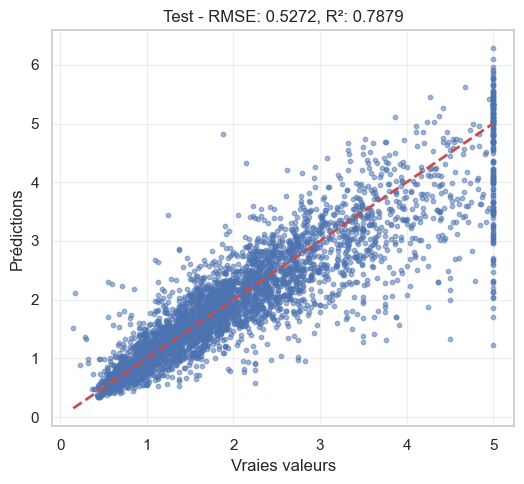

In [46]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_test_raw, y_pred_test_2, alpha=0.5, s=10)
plt.plot(
    [y_test_raw.min(), y_test_raw.max()],
    [y_test_raw.min(), y_test_raw.max()],
    'r--', lw=2
)
plt.xlabel('Vraies valeurs')
plt.ylabel('Prédictions')
plt.title(f'Test - RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 11. Sauvagarde du meilleur modèle

In [47]:
# Sauvegarde du modèle de scaling
joblib.dump(scaler, "Scaler.joblib")

['Scaler.joblib']

In [48]:
# Sauvegarde du modèle de scaling
joblib.dump(rf_model, "RandomForest.joblib")

['RandomForest.joblib']

In [11]:
joblib.dump(lin_geo, "GeoAxisModel.joblib")

['GeoAxisModel.joblib']